# Проект модуля 3. Предсказание возраста посетителей сайтов.

## Цель и задачи.
### Цель:
Увеличение эффективности интернет-рекламы за счет ее возрастного таргетирования на основании профиля поведения пользователей.

### Задачи:
1. Загрузка данных и знакомство с их содержимым.
2. Исследовательский анализ данных.
3. Предобработка данных для машинного обучения.
4. Обучение и оценка базовой модели классификации.
3. Отбор и создание признаков для задачи машинного обучения.
3. Подбор гиперпараметров моделей.
4. Финальное обучение моделей и подготовка артефактов.
5. Формулировка выводов, содержащих оценку и анализ результатов обучения моделей.

### Постановка задачи в терминах машинного обучения
- Необходимо решить задачу машинного обучения для предсказания возрастной категории интернет-пользователя на основе предоставленного датасета с признаками и значениями целевой переменной.
- Тип задачи машинного обучения: многоклассовая классификация.
- Целевая переменная - возрастная категория (см. `age_category` далее).
- Модели машинного обучения - многоклассовая логистическая регрессия и метод опорных векторов (SVM) с линейным и нелинейными ядрами в стратегиях One vs One и One vs Rest.
- Необходимо использовать кросс-валидацию по стратифицированным по значениям целевой переменной фолдам для оценки качества моделей.
- Основная метрика - F1 . Вспомогательные метрики - Precision, Recall. 
- Значение F1-меры лучшей модели должно быть не меньше 0.75 и на кросс-валидации по обучающей выборке, и на тестовой выборке. 
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.
- Для тестовой выборки необходимо выделить 20%-30% измерений из датасета.
- Решение должно быть сохранено в виде готового к промышленной эксплуатации пайплайна, включающего предобработку данных и классификатор.

### Описание данных
#### **Таблица `users`**

Таблица `users` содержит информацию о возрастной категории пользователя:

- `user_id` — уникальный идентификатор пользователя.
- `age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Содержит следующие категории:
    - `0`: младше 18;
    - `1`: 18-25 лет;
    - `2`: 26-40 лет;
    - `3`: 41-55 лет;
    - `4`: 56+ лет.

#### **Таблица `visits`**

Лог посещений сайтов `visits` похож на данные сервиса веб-аналитики [«Яндекс Метрика»](https://yandex.ru/adv/metrika). Он предназначен для сбора и анализа информации об активности пользователей разных сайтов. Заказчик попросил в целях защиты персональных данных заменить в логах все URL на анонимизированную категорию сайта, а вместо точного времени использовать время суток.

Признаки в датасете:

- `date` — дата посещения сайта.
- `daytime` — анонимизированное время посещения сайта. Категории: `утро`, `день`, `вечер`, `ночь`.
- `session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
- `user_id` — уникальный идентификатор пользователя.
- `website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.

#### **Таблица `ads_activity`**

Активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом. Информация об этом признаке представлена в таблице `ads_activity`:

- `user_id` — уникальный идентификатор пользователя.
- `ads_activity` — характеристика CTR, выраженная одним из значений: `очень редко`, `редко`, `умеренно`, `часто`, `очень часто`.

CTR (Click-Through Rate) — термин в интернет-маркетинге, показатель кликабельности. Показывает, как часто люди кликают по объявлению с рекламой, ссылке в поисковой выдаче или кнопке.

#### **Таблица `surf_depth`**

В таблице `surf_depth` содержится два признака:

- `user_id` — уникальный идентификатор пользователя.
- `surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории `поверхностно`, `средне`, `глубоко`.

#### **Таблица `primary_device`**

Таблица `primary_device` содержит два признака:

- `user_id` — уникальный идентификатор пользователя.
- `primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.

Каждое устройство и браузер, которым человек пользуется для выхода в интернет, имеет свой уникальный идентификатор. Крипта умеет определять, что все эти идентификаторы принадлежат одному пользователю, по схожести его поведения на разных устройствах или по более точным факторам: например, по использованию одного и того же логина. Также учитывается, что одним устройством могут пользоваться сразу несколько человек: члены семьи или коллеги. 

#### **Таблица `cloud_usage`**

Использование облачных технологий описано в файле `cloud_usage`:

- `user_id` — уникальный идентификатор пользователя;
- `cloud_usage` — `True` означает, что пользователь обращается к облачным ресурсам прямо или через посещаемые сайты.


## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовка библиотек
- Установка необходимых пакетов:

In [3]:
# %pip install -q numpy==1.23
# %pip install -q --upgrade scikit-learn
# %pip install -q --upgrade seaborn
# %pip install -q --upgrade jinja2
# %pip install -q phik
# %pip install -q mlxtend

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


- Импортируем необходимые пакеты:

In [4]:
import pandas as pd
import numpy as np
import phik

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.frozen import FrozenEstimator
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, \
    average_precision_score, log_loss, recall_score, precision_score, brier_score_loss
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

#### 1.2 Фиксация константы для воспроизводимости
- Зафиксируем значение `random_state` для воспроизводимости результатов:

In [5]:
RANDOM_SEED=42

#### 1.3 Загрузка данных
- Загрузим данные из датасета и выведем основные сведения о них:

In [6]:
def load_dataset(file_name):
    base_url = 'https://code.s3.yandex.net/'
    try:
        # Сначала загрузим данныз из локального файла
        return pd.read_csv(file_name)
    except FileNotFoundError:
        # Если файла нет, загружаем по сети
        return pd.read_csv(base_url + file_name)
    
df_users = load_dataset('datasets/ds_s13_users.csv')
df_visits = load_dataset('datasets/ds_s13_visits.csv')
df_ads_activity = load_dataset('datasets/ads_activity.csv')
df_surf_depth = load_dataset('datasets/surf_depth.csv')
df_primary_device = load_dataset('datasets/primary_device.csv')
df_cloud_usage = load_dataset('datasets/cloud_usage.csv')

dfs = [df_users, df_visits, df_ads_activity, df_surf_depth, df_primary_device,
       df_cloud_usage]

def show_df_info(dfs, names):
    for df, name in zip(dfs, names):
        display(HTML('<h2>Таблица ' + name + '</h2>'))
        display(df.info())
        display(df.head(10))
        display(HTML(f'<b>Количество явных дубликатов: {df.duplicated().sum()}<br> \
        Максимальное количество записей для одного user_id: \
                     {df.groupby(by='user_id').size().max()}</b>'))

show_df_info(dfs, ['users', 'visits', 'ads_activity', 
                          'surf_depth', 'primary_device', 'cloud_usage'])


<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


None

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0
5,348c-35488a73fb49d5b0449e-1920481e,0
6,f3cd-a32250aea93b5a3d6e48-2f6d3c21,2
7,d289-e3226cd63d5718a55b6e-4fcb65c0,4
8,b5ff-7828dbb91d99930fcc3f-48617440,4
9,5614-40eb0cb16aae973189dd-58d4abb3,4


<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB


None

...

None

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК
5,b252-4ef81d7eb4d08e7cfca3-8ab368c3,ПК
6,cf6c-8e40f0911cda3887386b-2a2ba17c,смартфон
7,d548-dcf590448cab64164ceb-9438f37d,планшет
8,05ce-a078ac0dc4bb3c6e7c85-a18923e0,планшет
9,e24f-3c900f4e1c090af800c4-14c13da3,смартфон


<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


None

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False
5,eec4-ba0e8feda1f4905f3d3d-8dca4ae5,False
6,055a-073f4618b55436f41f81-1f2d7d6f,True
7,b41c-a3e6a59e9b11f68bb6b7-90bd2a1e,False
8,ef6e-8deb3c158fa74aed8af5-a3412641,False
9,d8ed-37f46ad2607209a2eee3-2d85128e,False


#### 1.4. Удаление дубликатов и построение единого датасета
- В таблицах `users`, `visits`, `ads_activity` найдены дубликаты. В таблице `visits` они вполне возможны, так как в течение дня и в рамках одной сессии пользователь может совершать множество действий. В остальных таблицах дубликаты ошибочны и должны быть удалены:

In [7]:
df_users.drop_duplicates(inplace=True)
df_ads_activity.drop_duplicates(inplace=True)

show_df_info([df_users, df_ads_activity], ['df_users', 'df_ads_activity'])

<class 'pandas.DataFrame'>
Index: 5826 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   age_category  5826 non-null   int64
dtypes: int64(1), str(1)
memory usage: 136.5 KB


None

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0
5,348c-35488a73fb49d5b0449e-1920481e,0
6,f3cd-a32250aea93b5a3d6e48-2f6d3c21,2
7,d289-e3226cd63d5718a55b6e-4fcb65c0,4
8,b5ff-7828dbb91d99930fcc3f-48617440,4
9,5614-40eb0cb16aae973189dd-58d4abb3,4


<class 'pandas.DataFrame'>
Index: 5593 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5593 non-null   str  
 1   ads_activity  5593 non-null   str  
dtypes: str(2)
memory usage: 131.1 KB


None

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно
5,f00c-1bf1415b4377c2c229ee-cef74c27,умеренно
6,55ba-bb355dd086987f5f390f-508cb1cc,умеренно
7,ff8f-8167e729650d17c3add4-205d9000,очень редко
8,dcdf-429ea4cf29bc0f31762d-041e3a8c,редко
9,e57e-1590a765ad1fbfb7b81b-82ebe9fb,очень редко


- Выделим год, число и месяц в отдельные стобцы;
- Построим две сводные таблицы на базе `visits`: 
    1. С количеством посещений для каждой категории и времени суток по `user_id` и дням так, чтобы для одного пользователя и даты осталось по одной строке.
    2. С суммарным количеством посещений и категориальными значениями по `user_id` без учета даты.
- В сводных таблицах переименуем столбцы, чтобы их названия были английскими, в стиле snake case.

In [ ]:
# Сводная таблица со столбцами по категориям daytime
df_visits_daytime = df_visits.pivot_table(index=['user_id', 'date'],
                                        columns='daytime',
                                        values='session_id',
                                        aggfunc='count',
                                        fill_value=0)

# Сводная таблица со столбцами по категориям website_category
df_visits_category = df_visits.pivot_table(index=['user_id', 'date'],
                                        columns='website_category',
                                        values='session_id',
                                        aggfunc='count',
                                        fill_value=0)
print('Размер таблицы df_visits_daytime:', df_visits_category.shape)
print('Размер таблицы df_visits_category:', df_visits_daytime.shape)

display(df_visits_daytime.head())

# Сводная таблица по дням и user_id
df_visits_pivot_days = df_visits_daytime.join(df_visits_category, how='outer')
df_visits_pivot_days.reset_index(inplace=True)
print('Размер таблицы df_visits_pivot_days:', df_visits_pivot_days.shape)
display(HTML(f'<b>Диапазон дат: с {df_visits_pivot_days['date'].min()} по {df_visits_pivot_days['date'].max()}'))
df_visits_pivot_days[['year', 'month', 'day']] = (df_visits_pivot_days['date']
                                             .str
                                             .split('-', expand=True)
                                             .apply(pd.to_numeric))
cols_to_rename = {
    'вечер': 'evening_time',
    'ночь': 'night_time',
    'день': 'day_time',
    'утро': 'morning_time'    
}

# Переименование столбцов
cols_to_rename.update({f'Category {i:02}': f'cat_{i:02}' for i in range(1, 21)})
df_visits_pivot_days.rename(columns=cols_to_rename, inplace=True)

display(df_visits_pivot_days.info())
display(df_visits_pivot_days.head())

Размер таблицы df_visits_daytime: (81556, 20)
Размер таблицы df_visits_category: (81556, 4)


count               
daytime                                       вечер день ночь утро
user_id                            date                           
0010-5cf8f6b38a7b6c70a021-009dbcda 2025-11-01    15   15    3   10
                                   2025-11-02    14   13    3    6
                                   2025-11-03    12   13    6    6
                                   2025-11-04    13   10    8    6
                                   2025-11-05    16   13    4    5

MergeError: Not allowed to merge between different levels. (2 levels on the left, 1 on the right)

- Создадим таблицу с агрегированными по `user_id` значениями:

In [ ]:

sum_cols = ['evening_time',
            'day_time',
            'night_time',
            'morning_time'] + [f'cat_{i:02}' for i in range(1, 21)]
agg_dic = {col: 'sum' for col in sum_cols}
agg_dic['date'] = 'count'

# Создадим таблицу с агрегированными по user_id значениями
df_visits_pivot_sum = (df_visits_pivot_days
                       .groupby('user_id')[list(agg_dic.keys())]
                       .agg(agg_dic))
df_visits_pivot_sum.rename(columns={'date': 'days_count'}, inplace=True)
print(HTML(f"<b>Размер таблицы df_visits_pivot_sum: {df_visits_pivot_sum.shape}"))

display(df_visits_pivot_sum.info())
display(df_visits_pivot_sum.head())

<IPython.core.display.HTML object>
<class 'pandas.DataFrame'>
Index: 5826 entries, 0010-5cf8f6b38a7b6c70a021-009dbcda to ffbf-71c28263b860736010d4-a0ee88f3
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   evening_time  5826 non-null   int64
 1   day_time      5826 non-null   int64
 2   night_time    5826 non-null   int64
 3   morning_time  5826 non-null   int64
 4   cat_01        5826 non-null   int64
 5   cat_02        5826 non-null   int64
 6   cat_03        5826 non-null   int64
 7   cat_04        5826 non-null   int64
 8   cat_05        5826 non-null   int64
 9   cat_06        5826 non-null   int64
 10  cat_07        5826 non-null   int64
 11  cat_08        5826 non-null   int64
 12  cat_09        5826 non-null   int64
 13  cat_10        5826 non-null   int64
 14  cat_11        5826 non-null   int64
 15  cat_12        5826 non-null   int64
 16  cat_13        5826 non-null   int64
 17  cat_14        5826 non-null

None

,evening_time,day_time,night_time,morning_time,cat_01,cat_02,cat_03,cat_04,cat_05,cat_06,...,cat_12,cat_13,cat_14,cat_15,cat_16,cat_17,cat_18,cat_19,cat_20,days_count
user_id,,,,,,,,,,,,,,,,,,,,,
0010-5cf8f6b38a7b6c70a021-009dbcda,227,182,54,92,16,0,34,24,18,30,...,44,12,19,15,33,28,44,50,51,14
0013-4ae5f7d127b91a3fb0f8-ba59f141,52,69,17,49,15,11,6,7,15,7,...,0,12,7,3,8,12,17,1,4,14
0014-d3032d60979a8d2b3077-f09bdce8,36,47,11,26,1,2,5,7,8,6,...,7,20,8,8,2,9,3,12,4,14
001a-eee53e44f848608779b0-78704a67,121,96,32,42,19,13,10,23,10,9,...,19,0,28,12,9,13,21,21,17,14
002c-40a064b12e1217e12207-a56eaf3b,150,192,34,124,0,28,36,30,20,20,...,43,83,0,22,20,18,6,25,28,14


- Соединим все таблицы в один датафрейм по `user_id`:

In [10]:
df_user_props = (df_users.merge(df_surf_depth, on='user_id', how='left')
      .merge(df_ads_activity, on='user_id', how='left')
      .merge(df_cloud_usage, on='user_id', how='left')
      .merge(df_primary_device, on='user_id', how='left'))
df = df_user_props.merge(df_visits_pivot_days, on='user_id', how='left')
df_sum = df_user_props.merge(df_visits_pivot_sum, on='user_id', how='left')

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 81556 entries, 0 to 81555
Data columns (total 34 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         81556 non-null  str   
 1   age_category    81556 non-null  int64 
 2   surf_depth      80002 non-null  str   
 3   ads_activity    78294 non-null  str   
 4   cloud_usage     79512 non-null  object
 5   primary_device  79358 non-null  str   
 6   date            81556 non-null  str   
 7   evening_time    81556 non-null  int64 
 8   day_time        81556 non-null  int64 
 9   night_time      81556 non-null  int64 
 10  morning_time    81556 non-null  int64 
 11  cat_01          81556 non-null  int64 
 12  cat_02          81556 non-null  int64 
 13  cat_03          81556 non-null  int64 
 14  cat_04          81556 non-null  int64 
 15  cat_05          81556 non-null  int64 
 16  cat_06          81556 non-null  int64 
 17  cat_07          81556 non-null  int64 
 18  cat_08          8

None

- Пропуски присутствуют в столбцах `surf_depth`, `ads_activity`, `cloud_usage`, `primary_device`. В булевом столбце `cloud_usage`, вероятно, значение отсутствует для пользователей, не зарегистрированных в облачном сервисе, поэтому его можно заменить на `False` и преобразовтаь столбец к булевому типу. Пропуски в остальных столбцах заменим на индикатор `Unknown`.
- Переименуем столбцы, чтобы их названия были английскими в стиле snake case.
- Добавим столбец `total` с суммарным количеством обращений за день.

In [11]:
# Заполнение пропусков
df['cloud_usage'] = pd.to_numeric(df['cloud_usage'].fillna(False))
df['surf_depth'] = df['surf_depth'].fillna('Unknown')
df['ads_activity'] = df['ads_activity'].fillna('Unknown')
df['primary_device'] = df['primary_device'].fillna('Unknown')

df['total'] = df['morning_time'] + df['day_time'] + \
                df['evening_time'] + df['night_time']

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 81556 entries, 0 to 81555
Data columns (total 35 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         81556 non-null  str  
 1   age_category    81556 non-null  int64
 2   surf_depth      81556 non-null  str  
 3   ads_activity    81556 non-null  str  
 4   cloud_usage     81556 non-null  bool 
 5   primary_device  81556 non-null  str  
 6   date            81556 non-null  str  
 7   evening_time    81556 non-null  int64
 8   day_time        81556 non-null  int64
 9   night_time      81556 non-null  int64
 10  morning_time    81556 non-null  int64
 11  cat_01          81556 non-null  int64
 12  cat_02          81556 non-null  int64
 13  cat_03          81556 non-null  int64
 14  cat_04          81556 non-null  int64
 15  cat_05          81556 non-null  int64
 16  cat_06          81556 non-null  int64
 17  cat_07          81556 non-null  int64
 18  cat_08          81556 non-null  int64

None

#### Выводы:
- Был представлен датасет, состоящий из 5 таблиц в формате CSV.
- Датасет был проанализирован на наличие дубликатов. Дубликаты были найдены в трех таблицах: `users`, `visits`, `ads_activity`. Наличие дубликатов в таблице `visits` не является ошибкой; в остальных таблицах дубликаты были удалены.
- После удаления дубликатов количество пользователей в датасете `users` равно 5826.
- Таблица `visits` была преобразована в сводную путем подсчета количества строк в каждой из категорий, задаваемых столбцами `daytime`, `website_category`. Столбец `date` был разбит на три: `day`, `month`, `year`.
- Все таблицы датасета были объединены в единый датафрейм пр помощи внешних соединений с таблицей `users` по полю `user_id`.
- Пропуски в столбцах, появившиеся в результате внешних соединений были заполнены следующим образом: 
    1. В столбце `cloud_usage` - значением `False`;
    2. В столбцах `surf_depth`, `ads_activity`, `primary_device` - значением-индикатором `Unknown`.
- Был добавлен признак `total`, содержащий суммарное количество обращений пользователя за день.

## 2. Исследовательский анализ данных
- Описание функций для построения графиков и диаграмм:

In [12]:
# Функция для построения скаттерплота в сетке
def draw_scatterplot_grid(data, 
                     title, 
                     x, 
                     y, 
                     hue,
                     xlabel, 
                     ylabel,
                     ax):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue, 
                    ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# Функция для построения боксплота в сетке
def draw_boxplot_grid(data,
                    field,
                    title, 
                    xlabel, 
                    ylabel, 
                    **kwargs):
    sns.boxplot(data=data,
                x=field,   
                showmeans=True,
                legend=False,
                meanprops={
                    'marker': 'o',
                    'markerfacecolor': 'white',
                    'markeredgecolor': 'black',
                    'markersize': 8
                },
                orient='h',
                **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения в сетке
def draw_histogram(data,
                    field,
                    title,
                    xlabel, 
                    ylabel,
                    figsize=(12,6),
                    **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    plt.figure(figsize=figsize)
    plt.title(title)
    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot, 
                 vertical, 
                 mean,
                 ax):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        ax=ax)
    
    if mean != None:
        if vertical:
            ax.axhline(mean, color='red', linestyle='--')
        else:
            ax.axvline(mean, color='red', linestyle='--')    

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(12,12), font_scale=0.8):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()    

# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, hue, xlabel, ylabel, stat='count', figsize=(12, 6), bins='auto', kde=True):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    'marker': 'o',
                    'markerfacecolor': 'white',
                    'markeredgecolor': 'black',
                    'markersize': 8
                })

    ax_box.set_xlabel('')  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat)

    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    # Функция для построения столбчатой диаграммы
def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

- Разделение признаков на числовые и категориальные (поскольку данные приведены только за две недели ноября 2025 года, от даты можно оставить только день в качестве категориального признака):

In [13]:
num_features = [
    'morning_time',
    'day_time',
    'evening_time',
    'night_time',
    'total'
].extend([f'cat_{i:02}' for i in range(1, 21)])

cat_features = [
    'surf_depth',
    'ads_activity',
    'primary_device'
]

bool_features = ['cloud_usage']
target = 'age_category'

- Исследуем распределение классов целевой переменной:

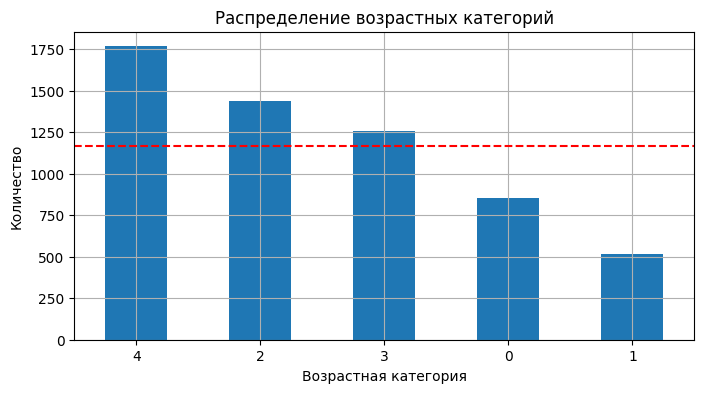

In [14]:
age_cat_qty_mean = df_users['age_category'].value_counts().mean()
draw_barplot(df_users['age_category'].value_counts(), 
             "Распределение возрастных категорий", 
             "Возрастная категория",
             "Количество",
             mean=age_cat_qty_mean)

- Видно, что среди пользователей старше 26 лет их количество растет пропорционально возрастной категории. Пользователей младше 18 лет больше, чем пользователей 18-25 лет.
- Классы не сбалансированы. Самый многочисленный класс более, чем в 3 раза превосходит самый маленький.

- Построим диаграмму среднего количества обращений по дням в зависимости от возрастной категории:

day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,13.078828,13.014187,13.069240,13.056265,12.985089,13.045655,12.966048,13.063648,12.998056,13.013345,13.040854,13.023372,13.108111,12.933085
std,0.203263,0.236150,0.356335,0.365137,0.356745,0.322600,0.477491,0.449727,0.478586,0.367618,0.348282,0.240844,0.289174,0.460076
min,12.828426,12.659533,12.540856,12.503891,12.564202,12.558366,12.227626,12.466926,12.254864,12.472763,12.538911,12.672140,12.772374,12.357977
25%,12.887160,12.929785,12.878256,12.864100,12.688385,12.938810,12.779728,12.691959,12.797848,12.804077,12.872027,12.931907,12.908834,12.557758
50%,13.212441,13.049238,13.194607,13.240829,13.015288,13.098476,13.155920,13.356498,13.214789,13.158265,13.073857,13.084408,13.049238,13.028136
75%,13.218902,13.155664,13.359277,13.321975,13.270809,13.221140,13.219597,13.381008,13.281499,13.298819,13.347687,13.105263,13.371611,13.351157
max,13.247209,13.276715,13.373206,13.350528,13.386762,13.411483,13.447368,13.421850,13.441279,13.332801,13.371786,13.323141,13.438499,13.370396


age_category,0,1,2,3,4
count,14.000000,14.000000,14.000000,14.000000,14.000000
mean,13.165837,12.552668,13.293733,13.328246,12.800867
std,0.111893,0.208336,0.116876,0.090682,0.112239
min,13.028136,12.227626,13.015288,13.105263,12.557758
25%,13.076495,12.468385,13.219983,13.277911,12.713901
50%,13.157093,12.539883,13.322558,13.349422,12.816251
75%,13.214202,12.635700,13.367616,13.383373,12.876699
max,13.381008,12.931907,13.441279,13.447368,12.938810


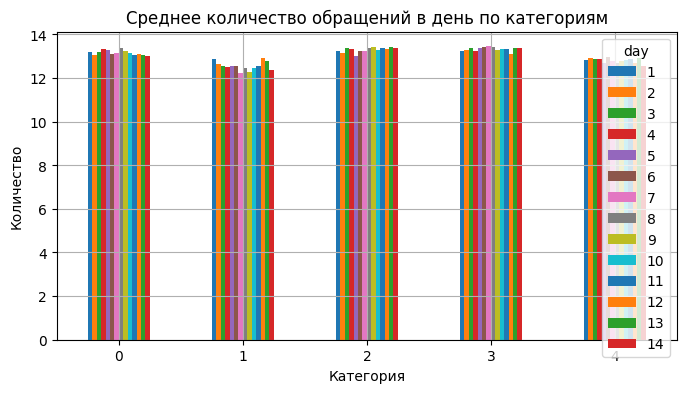

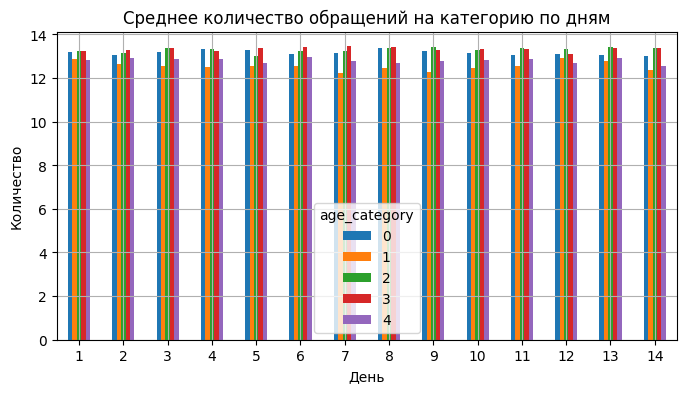

In [15]:
df_by_cats = df.groupby(['age_category', 'day'])['total'].mean().unstack()
df_by_days = df.groupby(['day', 'age_category'])['total'].mean().unstack()
display(df_by_cats.describe())
display(df_by_days.describe())
draw_barplot(df_by_cats, "Среднее количество обращений в день по категориям", "Категория", "Количество")
draw_barplot(df_by_days, "Среднее количество обращений на категорию по дням", "День", "Количество")

- Построим диаграммы распределения категориальных признаков:

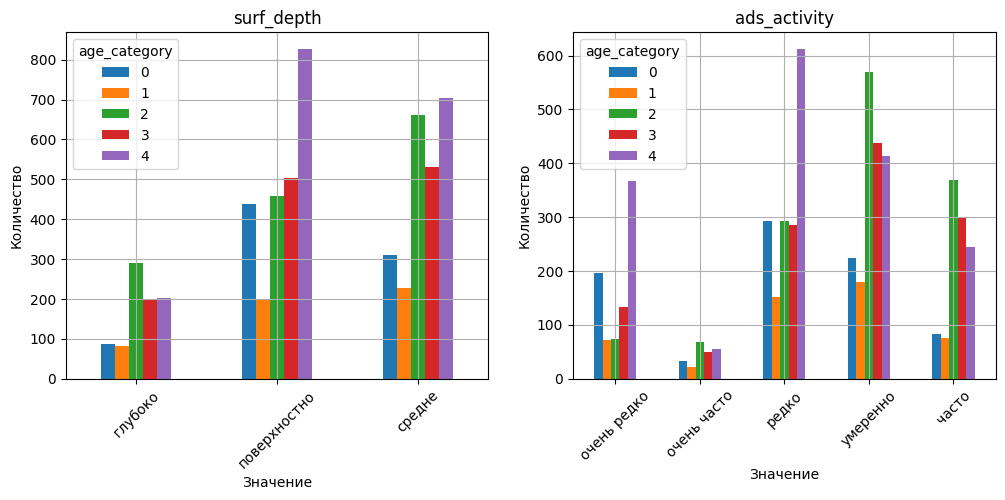

In [23]:
fig, axes = plt.subplots(len(cat_features) // 2, 2, figsize=(12, len(cat_features) * 1.5))

for i, ax in enumerate(axes.flatten()):
    draw_barplot_grid(
            # (df
            # .groupby(by=cat_features[i // 2])['click']
            # .value_counts()
            # .unstack(fill_value=0)
            # .sort_values(by=0, ascending=False)),
            (df_sum
             .groupby(cat_features[i])['age_category']
             .value_counts()
             .unstack(fill_value=0)),
            cat_features[i], 
            "Значение", 
            "Количество", 
            45, 
            True, 
            None,
            ax)